# 07b — Identity Anomaly Detection: Extended Red-Team Evaluation on LANL

Companion to **07_identity_redteam_evaluation.ipynb**. Reproduces the extended, feature-attribution
experiments in the paper *"Access Breadth over Ensembles: A Red-Team Evaluation of Unsupervised
Identity Anomaly Detection on the LANL Dataset."* Everything needed to re-run is in this notebook;
it mirrors `paper/identity/eval_extras.py`.

**What this notebook shows**
1. **Per-feature univariate AUC** — which of the 9 features actually carries the red-team signal
   (the core evidence that *access breadth* dominates).
2. **Feature-group Isolation Forests** — time-3, behavioural-2, categorical-4, all-9.
3. **Leave-one-out** — how the ensemble AUC changes when each feature is removed.
4. **Red vs normal distributions** — the "broad-access, not high-volume" signature.
5. **Access-breadth threshold rule** — a near-parameter-free detector (cf. Bowman's Unknown
   Authentication rule).
6. **Ranking metrics** — recall-at-fixed-FPR and precision@top-K, the deployment-realistic view
   under a prevalence of ~6e-5.
7. **Subsample invariance** — AUC recomputed at negative-subsample rates 1/40, 1/80, 1/160.

**Reproducibility notes**
- **Deterministic categorical encoding.** Categorical protocol fields (logon/auth type, orientation,
  success) are label-encoded with **sorted** category order. Polars' `unique()` order is
  non-deterministic, and Isolation Forest treats the integer codes as ordinal, so an unsorted mapping
  makes the ensemble AUC irreproducible. Sorting fixes this. (The raw-count features `unique_pcs` and
  `hourly_count` are encoding-independent, so the headline finding is deterministic regardless.)
- **Data required:** `data/raw/auth_window.csv` (the red-team window extracted from the raw LANL
  `auth.txt.gz`; see the README runbook for the one-line `awk` extractor) and `data/raw/redteam.txt.gz`.
- All randomness is seeded (42). Numbers match `paper/identity/results_identity.json`.
- **Memory/time:** the window CSV is ~3.4 GB; Polars streams it. Each full pass takes a few minutes,
  and the notebook loads it ~3× (once for the main analysis, twice more for the invariance check),
  so budget ~10-15 minutes on a workstation.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             roc_auc_score, roc_curve)
from sklearn.preprocessing import StandardScaler

# --- locate project root (folder containing data/processed) ---
ROOT = Path.cwd()
while not (ROOT / 'data' / 'processed').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA_RAW = ROOT / 'data' / 'raw'
WINDOW_CSV = DATA_RAW / 'auth_window.csv'
REDTEAM = DATA_RAW / 'redteam.txt.gz'

WINDOW = (150_000, 500_000)   # seconds; red-team activity starts ~day 2 (150k s)
NEG_HASH_MOD = 80             # keep all positives + ~1/80 of negatives
SEED = 42
rng = np.random.default_rng(SEED)

COLS = ['time', 'src_user', 'src_pc', 'dst_pc', 'auth_type', 'logon_type', 'orientation', 'success']
FEATURES = ['hour', 'day_of_week', 'is_weekend', 'hourly_count', 'unique_pcs',
            'logon_type_code', 'auth_type_code', 'orientation_code', 'success_code']
GROUPS = {
    'time_3': ['hour', 'day_of_week', 'is_weekend'],
    'behavioural_2': ['hourly_count', 'unique_pcs'],
    'categorical_4': ['logon_type_code', 'auth_type_code', 'orientation_code', 'success_code'],
    'all_9': FEATURES,
}
print('root:', ROOT)
print('window CSV present:', WINDOW_CSV.exists(), '| redteam present:', REDTEAM.exists())

root: C:\Users\User\ai-cybersecurity-portfolio
window CSV present: True | redteam present: True


## Loading and feature engineering

We build the labelled, subsampled event table exactly as the deployed evaluation does. Behavioural
aggregates (`hourly_count`, `unique_pcs`) are computed over the **full** window *before* subsampling,
so subsampling only changes which negatives are scored, not the feature values. The `build_sample`
function is parameterised by the negative-subsample rate so we can reuse it for the invariance check.

In [2]:
def build_sample(neg_hash_mod):
    """Return (sample_df, X [n,9] float64, y [n] int) for a given negative-subsample rate."""
    # red-team keys inside the window (join on time, src_user, src_pc)
    rt = pl.read_csv(REDTEAM, has_header=False, new_columns=['time', 'src_user', 'src_pc', 'dst_pc'])
    rt = rt.filter((pl.col('time') >= WINDOW[0]) & (pl.col('time') <= WINDOW[1]))
    rt_keys = rt.select(['time', 'src_user', 'src_pc']).unique().with_columns(pl.lit(1).alias('is_red'))

    # lazy scan of the window; derive time features
    lf = pl.scan_csv(WINDOW_CSV, has_header=False, new_columns=COLS)
    lf = lf.with_columns([
        ((pl.col('time') % 86400) // 3600).alias('hour'),
        ((pl.col('time') // 86400) % 7).alias('day_of_week'),
    ]).with_columns(pl.col('day_of_week').is_in([5, 6]).cast(pl.Int64).alias('is_weekend'))

    # behavioural aggregates over the FULL window
    hourly = lf.group_by(['src_user', 'hour']).agg(pl.len().alias('hourly_count')).collect(engine='streaming')
    pcs = lf.group_by('src_user').agg(pl.col('src_pc').n_unique().alias('unique_pcs')).collect(engine='streaming')

    # label, then keep all positives + a deterministic hash-subsample of negatives
    labelled = lf.join(rt_keys.lazy(), on=['time', 'src_user', 'src_pc'], how='left').with_columns(
        pl.col('is_red').fill_null(0))
    keyhash = pl.concat_str(['time', 'src_user', 'src_pc', 'dst_pc'], separator='|').hash()
    sample = labelled.filter((pl.col('is_red') == 1) | ((keyhash % neg_hash_mod) == 0)).collect(engine='streaming')

    sample = sample.join(hourly, on=['src_user', 'hour'], how='left').join(pcs, on='src_user', how='left')
    for col in ['logon_type', 'auth_type', 'orientation', 'success']:
        cats = sorted(sample[col].unique().to_list())    # DETERMINISTIC encoding (sorted!)
        mapping = {v: i for i, v in enumerate(cats)}
        sample = sample.with_columns(pl.col(col).replace_strict(mapping, default=-1).alias(f'{col}_code'))

    # total-order row sort: streaming joins don't preserve order, and Isolation Forest
    # samples rows by index, so unsorted/tie-broken rows -> irreproducible ensemble AUC.
    sample = sample.sort(['time', 'src_user', 'src_pc', 'dst_pc',
                          'auth_type', 'logon_type', 'orientation', 'success'])
    y = sample['is_red'].to_numpy()
    X = sample.select(FEATURES).to_numpy().astype(np.float64)
    return sample, X, y


def iso_auc(X, y, seed=SEED):
    """Fit Isolation Forest on the assumed-normal events, return (AUC, AP, scores)."""
    Xn = X[y == 0]
    scaler = StandardScaler().fit(Xn)
    iso = IsolationForest(n_estimators=200, random_state=seed, n_jobs=-1).fit(scaler.transform(Xn))
    score = -iso.score_samples(scaler.transform(X))      # higher = more anomalous
    return float(roc_auc_score(y, score)), float(average_precision_score(y, score)), score

print('building sample at neg 1/%d ...' % NEG_HASH_MOD)
sample, X, y = build_sample(NEG_HASH_MOD)
print(f'positives = {int(y.sum())}   negatives = {int((y==0).sum()):,}   '
      f'prevalence = {y.mean():.2e}')

building sample at neg 1/80 ...


positives = 48   negatives = 767,254   prevalence = 6.26e-05


## 1. Per-feature univariate AUC

Each raw feature value is used directly as an anomaly score (no training). This is the cleanest
statement of *which single feature separates red-team from normal*. `unique_pcs` (access breadth)
should dominate; `hourly_count` (login volume) should sit **below** 0.5 — red-team accounts are not
busier than normal ones. A feature with AUC < 0.5 is inversely related to the label; its
*discriminative power* is `max(auc, 1-auc)`.

In [3]:
rows = []
for i, f in enumerate(FEATURES):
    a = roc_auc_score(y, X[:, i])
    rows.append((f, a, max(a, 1 - a), 'higher=anomalous' if a >= 0.5 else 'lower=anomalous'))
rows.sort(key=lambda r: -r[2])
print(f'{"feature":<18}{"AUC":>8}{"discrim.":>10}   direction')
for f, a, d, dirn in rows:
    print(f'{f:<18}{a:>8.3f}{d:>10.3f}   {dirn}')

feature                AUC  discrim.   direction
auth_type_code       0.931     0.931   higher=anomalous
unique_pcs           0.905     0.905   higher=anomalous
orientation_code     0.665     0.665   higher=anomalous
is_weekend           0.616     0.616   higher=anomalous
hourly_count         0.423     0.577   lower=anomalous
hour                 0.573     0.573   higher=anomalous
logon_type_code      0.547     0.547   higher=anomalous
day_of_week          0.485     0.515   lower=anomalous
success_code         0.503     0.503   higher=anomalous


## 2. Feature-group Isolation Forests

We fit the same Isolation Forest on feature **groups** to see which group carries the signal and
whether combining them helps. Compare each group's AUC to the single-feature `unique_pcs` result
above and to the full 9-feature ensemble (`all_9`).

In [4]:
grp = {}
for name, feats in GROUPS.items():
    idx = [FEATURES.index(f) for f in feats]
    a, ap, _ = iso_auc(X[:, idx], y)
    grp[name] = a
    print(f'{name:<16} ({len(feats)}f)   AUC = {a:.4f}   AP = {ap:.5f}')

time_3           (3f)   AUC = 0.5098   AP = 0.00007


behavioural_2    (2f)   AUC = 0.8792   AP = 0.00028


categorical_4    (4f)   AUC = 0.9072   AP = 0.00052


all_9            (9f)   AUC = 0.9005   AP = 0.00032


## 3. Leave-one-out

Remove one feature at a time and refit. A **positive** delta means the ensemble got *better* without
that feature (i.e., the feature was hurting). This complements the univariate view: some features
that look weak alone still interact within the forest.

In [5]:
full = grp['all_9']
print(f'full 9-feature ensemble AUC = {full:.4f}\n')
print(f'{"drop feature":<18}{"AUC without":>12}{"delta vs full":>15}')
loo = []
for drop in FEATURES:
    idx = [i for i, f in enumerate(FEATURES) if f != drop]
    a, _, _ = iso_auc(X[:, idx], y)
    loo.append((drop, a, a - full))
for drop, a, d in sorted(loo, key=lambda r: -r[2]):
    print(f'{drop:<18}{a:>12.4f}{d:>+15.4f}')

full 9-feature ensemble AUC = 0.9005

drop feature       AUC without  delta vs full


logon_type_code         0.9272        +0.0267
hourly_count            0.9223        +0.0218
orientation_code        0.9165        +0.0160
hour                    0.9098        +0.0093
day_of_week             0.8855        -0.0150
success_code            0.8821        -0.0184
unique_pcs              0.8799        -0.0206
is_weekend              0.8744        -0.0261
auth_type_code          0.6024        -0.2981


## 4. Red-team vs normal distributions

Quantifies the access-breadth signature directly: red-team accounts touch far **more** distinct
machines (`unique_pcs`) than normal accounts, while their login **volume** (`hourly_count`) is not
elevated. This is why access breadth separates the classes and login volume does not.

In [6]:
def stats(v):
    return dict(mean=np.mean(v), median=np.median(v),
                p90=np.percentile(v, 90), p99=np.percentile(v, 99), max=np.max(v))
for f in ['unique_pcs', 'hourly_count']:
    v = X[:, FEATURES.index(f)]
    r, n = stats(v[y == 1]), stats(v[y == 0])
    print(f'{f}:')
    print(f'   red-team : mean={r["mean"]:.1f}  median={r["median"]:.0f}  p90={r["p90"]:.0f}  max={r["max"]:.0f}')
    print(f'   normal   : mean={n["mean"]:.1f}  median={n["median"]:.0f}  p90={n["p90"]:.0f}  max={n["max"]:.0f}\n')

unique_pcs:
   red-team : mean=55.5  median=68  p90=68  max=68
   normal   : mean=133.1  median=12  p90=20  max=4358

hourly_count:
   red-team : mean=259.9  median=215  p90=580  max=583
   normal   : mean=4713.3  median=205  p90=14221  max=65781



## 5. Access-breadth threshold rule

Access breadth is nearly parameter-free: just flag accounts that authenticate from at least *k*
distinct machines. This is the continuous analogue of Bowman et al.'s Unknown-Authentication rule.
We sweep *k* and report recall / precision / false-positive rate.

In [7]:
breadth = X[:, FEATURES.index('unique_pcs')]
print(f'{"k (>= machines)":<16}{"recall":>8}{"FPR":>10}{"precision":>12}{"TP":>6}{"FP":>10}')
for thr in [2, 3, 5, 10, 20, 50, 100]:
    pred = (breadth >= thr).astype(int)
    tp = int(((pred==1)&(y==1)).sum()); fp = int(((pred==1)&(y==0)).sum())
    fn = int(((pred==0)&(y==1)).sum()); tn = int(((pred==0)&(y==0)).sum())
    rec = tp/(tp+fn) if tp+fn else 0; prec = tp/(tp+fp) if tp+fp else 0; fpr = fp/(fp+tn) if fp+tn else 0
    print(f'{thr:<16}{rec:>8.2f}{fpr:>10.4f}{prec:>12.5f}{tp:>6}{fp:>10,}')

k (>= machines)   recall       FPR   precision    TP        FP
2                   1.00    0.9827     0.00006    48   753,946
3                   1.00    0.9450     0.00007    48   725,060
5                   0.98    0.9221     0.00007    47   707,457
10                  0.98    0.8110     0.00008    47   622,280
20                  0.98    0.1001     0.00061    47    76,791
50                  0.54    0.0771     0.00044    26    59,126
100                 0.00    0.0636     0.00000     0    48,789


## 6. Ranking metrics under extreme imbalance

At a prevalence of ~6e-5, precision at any fixed threshold is bounded near zero, so the meaningful
question is *how far up a ranked queue the true positives sit*. We report recall at fixed
false-positive budgets and precision among the top-K ranked events, for both the full Isolation
Forest and access breadth alone.

In [8]:
_, _, iso_score = iso_auc(X, y)

def recall_at_fpr(score, target):
    thr = np.quantile(score[y == 0], 1 - target)
    return float((score[y == 1] > thr).mean())

def prec_at_k(score, k):
    order = np.argsort(-score)[:k]
    return float(y[order].sum() / k)

print(f'{"metric":<18}{"Isolation Forest":>18}{"access breadth":>18}')
for tgt in [0.001, 0.01, 0.05, 0.10]:
    print(f'recall@FPR={tgt:<7}{recall_at_fpr(iso_score, tgt):>18.3f}{recall_at_fpr(breadth, tgt):>18.3f}')
for k in [50, 100, 500, 1000]:
    print(f'precision@{k:<8}{prec_at_k(iso_score, k):>18.3f}{prec_at_k(breadth, k):>18.3f}')

metric              Isolation Forest    access breadth
recall@FPR=0.001               0.000             0.000
recall@FPR=0.01                0.000             0.000
recall@FPR=0.05                0.000             0.000
recall@FPR=0.1                 0.646             0.958
precision@50                   0.000             0.000
precision@100                  0.000             0.000


precision@500                  0.000             0.000
precision@1000                 0.000             0.000


## 7. ROC / PR curves for the full detector

Regenerates the paper's ROC and precision-recall figures for the 9-feature Isolation Forest.

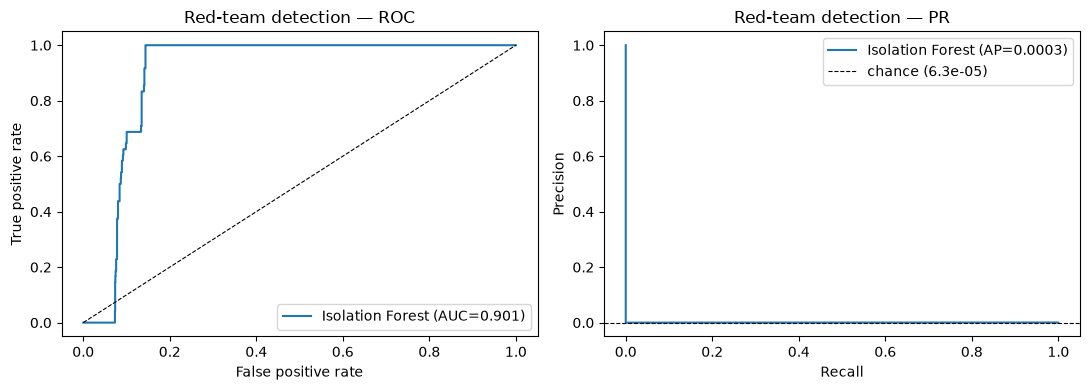

In [9]:
auc, ap, _ = iso_auc(X, y)
fpr_c, tpr_c, _ = roc_curve(y, iso_score)
prec_c, rec_c, _ = precision_recall_curve(y, iso_score)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(fpr_c, tpr_c, label=f'Isolation Forest (AUC={auc:.3f})')
ax[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='Red-team detection — ROC')
ax[0].legend(loc='lower right')
ax[1].plot(rec_c, prec_c, label=f'Isolation Forest (AP={ap:.4f})')
ax[1].axhline(y.mean(), color='k', ls='--', lw=0.8, label=f'chance ({y.mean():.1e})')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Red-team detection — PR')
ax[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

## 8. Subsample invariance

ROC AUC is a rank statistic, so uniform negative subsampling should not change it in expectation.
We confirm this empirically by recomputing the `unique_pcs` AUC at 1/40 and 1/160 (vs the 1/80 used
throughout). These extra loads are the slowest part of the notebook.

In [10]:
print(f'neg 1/80  : unique_pcs AUC = {roc_auc_score(y, breadth):.4f}   (positives={int(y.sum())}, negs={int((y==0).sum()):,})')
for mod in [40, 160]:
    _, Xm, ym = build_sample(mod)
    a = roc_auc_score(ym, Xm[:, FEATURES.index('unique_pcs')])
    print(f'neg 1/{mod:<3}: unique_pcs AUC = {a:.4f}   (positives={int(ym.sum())}, negs={int((ym==0).sum()):,})')

neg 1/80  : unique_pcs AUC = 0.9053   (positives=48, negs=767,254)


neg 1/40 : unique_pcs AUC = 0.9052   (positives=48, negs=1,536,138)


neg 1/160: unique_pcs AUC = 0.9052   (positives=48, negs=383,518)


## Takeaways

- **Access breadth (`unique_pcs`) is the signal.** As a single raw feature it separates red-team from
  normal better than the full nine-feature Isolation Forest — the central parsimony result.
- **Login volume is counterproductive.** `hourly_count` scores below chance: red-team accounts are
  *broad*, not *busy*.
- **The ensemble is not additive.** Time features carry essentially no signal, and the categorical
  codes are an encoding-dependent (hence fragile) source of apparent signal; the robust, interpretable
  feature is access breadth.
- **Extreme imbalance ⇒ triage, not alarms.** Precision at any fixed threshold is bounded near the
  base rate, so the detector is best used to rank events for analyst review.
- **Rank metrics are subsample-invariant**, confirming the AUC estimate is unbiased.

Full narrative, tables, and prior-work comparison (Euler, LMDetect, Bowman's UA rule) are in the
accompanying paper; machine-readable numbers are in `paper/identity/results_identity.json`.